[ZHANG] rows with best_mass>0: 739
[ZHANG] rows with acceptance-region present: 477
[ANDERSEN (2024)] usable rows after applying same skip rules: 739

=== Power-law slope fits on dN/dM (log-log) ===
Zhang all best-fits:          alpha = 1.23
Zhang acceptance-region only: alpha = 1.45
Andersen (2024):         alpha = 1.23

=== Log-normal fits on dN/dlog10M ===
Zhang all best-fits: mc = 0.094 Msun, sigma = 0.626 dex
Zhang acceptance-region only: mc = 0.083 Msun, sigma = 0.560 dex
Andersen (2024): mc = 0.093 Msun, sigma = 0.628 dex


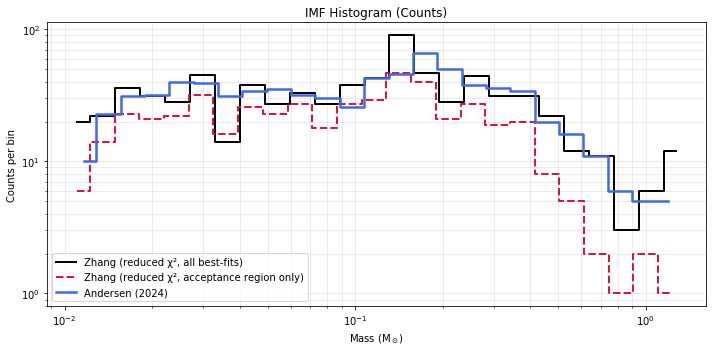

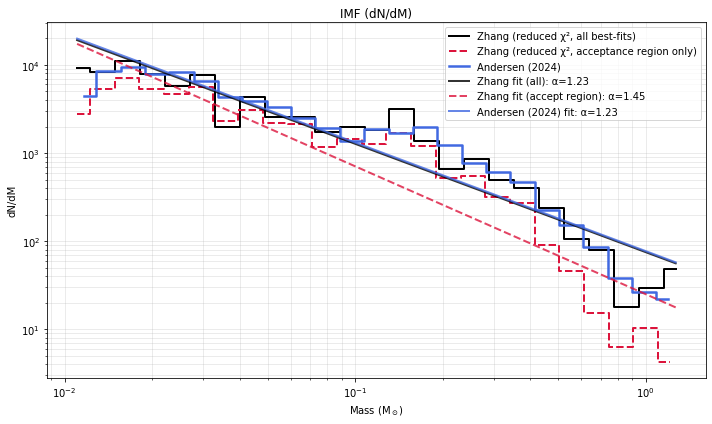

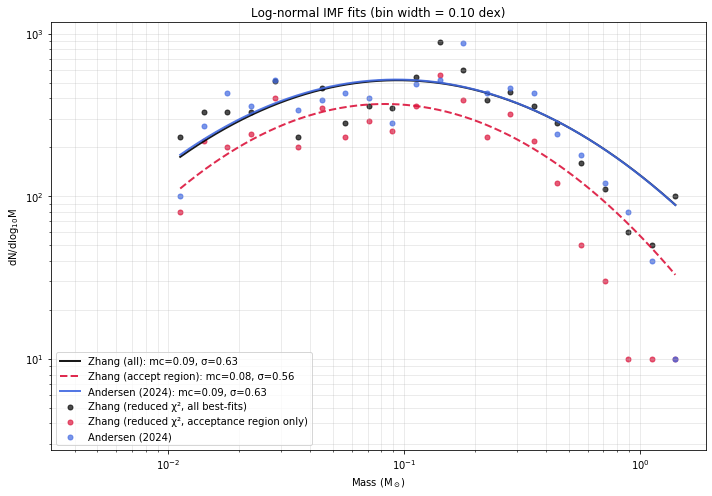

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# CONFIG: set these paths
# ============================================================
my_csv_path   = "../fit_results_jwst_hstall.csv"   # your fitter outputs (has best_mass, bounds, etc.)
his_dat_path  = "../phot_joined_avmass.dat"     # his master file with true_mass in last column

# Bin settings
nbins_logM = 25          # for dN/dM plots (log-spaced in M)
bin_width_dex = 0.10     # for dN/dlog10M log-normal fits

# ============================================================
# LOAD ZHANG MASSES (two samples: all best fits vs "acceptance region exists")
# ============================================================
df_my = pd.read_csv(my_csv_path)

# basic sanity
df_my = df_my.dropna(subset=["best_mass"]).copy()
df_my = df_my[df_my["best_mass"] > 0].copy()

# "Acceptance region exists" = bounds are present (your indicator of chi2 <= critical having non-empty set)
df_my["has_accept_region"] = df_my[["mass_min","mass_max","AV_min","AV_max"]].notnull().all(axis=1)

m_my_all = df_my["best_mass"].to_numpy()
m_my_acc = df_my.loc[df_my["has_accept_region"], "best_mass"].to_numpy()

print(f"[ZHANG] rows with best_mass>0: {len(m_my_all)}")
print(f"[ZHANG] rows with acceptance-region present: {len(m_my_acc)}")

# ============================================================
# LOAD ANDERSEN MASSES from .dat (true_mass is last column; apply SAME skip rules used in runner)
# ============================================================
his_masses = []
his_indices = []

with open(his_dat_path, "r") as f:
    for idx, line in enumerate(f):
        if line.startswith("#") or not line.strip():
            continue
        parts = [float(x) for x in line.split()]

        # Expect format (from your example):
        # x y F162M e162 F182M e182 F200W e200 F125W e125 F139M e139 F160W e160 true_AV true_mass
        # indices: 0 1 2    3    4    5    6    7    8    9    10   11   12   13   14      15
        if len(parts) < 16:
            continue

        mags = [parts[2], parts[4], parts[6], parts[8], parts[10], parts[12]]
        errs = [parts[3], parts[5], parts[7], parts[9], parts[11], parts[13]]
        true_av   = parts[14]
        true_mass = parts[15]

        # Apply your runner skip predicate (for jwst_hst mode):
        if any((m > 90 or e > 90 or e <= 0) for m, e in zip(mags, errs)) or true_av <= 0 or true_mass <= 0:
            continue

        his_masses.append(true_mass)
        his_indices.append(idx)

m_his = np.asarray(his_masses, dtype=float)

print(f"[ANDERSEN (2024)] usable rows after applying same skip rules: {len(m_his)}")

# ============================================================
# HELPERS: IMF histograms and power-law slope fits
# ============================================================
def imf_hist_dndm(masses, nbins=25):
    masses = np.asarray(masses)
    masses = masses[np.isfinite(masses) & (masses > 0)]
    if masses.size == 0:
        return None

    m_min = max(0.01, masses.min())
    m_max = masses.max()

    edges = np.logspace(np.log10(m_min), np.log10(m_max), nbins + 1)
    N, _ = np.histogram(masses, bins=edges)

    centers = np.sqrt(edges[:-1] * edges[1:])
    widths  = edges[1:] - edges[:-1]
    dndm = N / widths
    return centers, edges, N, dndm

def fit_powerlaw_slope(centers, dndm):
    # fit log10(dN/dM) = a*log10(M) + b  => IMF alpha = -a
    mask = (dndm > 0) & np.isfinite(dndm) & np.isfinite(centers) & (centers > 0)
    if mask.sum() < 3:
        return None
    logM = np.log10(centers[mask])
    logN = np.log10(dndm[mask])
    slope, intercept = np.polyfit(logM, logN, 1)
    alpha = -slope
    return alpha, slope, intercept

# ============================================================
# HELPERS: log-normal in dN/dlog10M (better for classic IMF log-normal fits)
# ============================================================
def lognormal_dndlogM(M, A, log10_mc, sigma_dex):
    logM = np.log10(M)
    return A * np.exp(-0.5 * ((logM - log10_mc) / sigma_dex) ** 2)

def make_dndlogM(masses, bin_width_dex=0.1):
    masses = np.asarray(masses)
    masses = masses[np.isfinite(masses) & (masses > 0)]
    if masses.size == 0:
        return None

    logM = np.log10(masses)
    lo = np.floor(logM.min() / bin_width_dex) * bin_width_dex
    hi = np.ceil(logM.max() / bin_width_dex) * bin_width_dex
    edges_log = np.arange(lo, hi + bin_width_dex, bin_width_dex)

    N, _ = np.histogram(logM, bins=edges_log)
    centers_log = 0.5 * (edges_log[:-1] + edges_log[1:])
    centers_M = 10 ** centers_log

    dndlog = N / bin_width_dex
    return centers_M, dndlog, N, edges_log

def fit_lognormal(centers_M, dndlog):
    mask = (dndlog > 0) & np.isfinite(dndlog) & np.isfinite(centers_M) & (centers_M > 0)
    x = centers_M[mask]
    y = dndlog[mask]
    if x.size < 3:
        return None

    A0 = np.nanmax(y)
    logmc0 = np.log10(x[np.nanargmax(y)])
    sigma0 = 0.3  # dex initial guess
    p0 = [A0, logmc0, sigma0]

    bounds = ([0.0, -5.0, 1e-3], [np.inf, 5.0, 2.0])
    popt, pcov = curve_fit(lognormal_dndlogM, x, y, p0=p0, bounds=bounds, maxfev=50000)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr

# ============================================================
# BUILD IMFs
# ============================================================
imf_my_all = imf_hist_dndm(m_my_all, nbins=nbins_logM)
imf_my_acc = imf_hist_dndm(m_my_acc, nbins=nbins_logM)
imf_his    = imf_hist_dndm(m_his,    nbins=nbins_logM)

if (imf_my_all is None) or (imf_his is None):
    raise RuntimeError("Not enough mass values to build one of the IMFs.")

c_my_all, e_my_all, N_my_all, dndm_my_all = imf_my_all
c_my_acc, e_my_acc, N_my_acc, dndm_my_acc = imf_my_acc if imf_my_acc else (None,)*4
c_his,    e_his,    N_his,    dndm_his    = imf_his

# Fit power-law slopes (optional but handy)
fit_all = fit_powerlaw_slope(c_my_all, dndm_my_all)
fit_acc = fit_powerlaw_slope(c_my_acc, dndm_my_acc) if imf_my_acc else None
fit_his = fit_powerlaw_slope(c_his,    dndm_his)

print("\n=== Power-law slope fits on dN/dM (log-log) ===")
if fit_all: print(f"Zhang all best-fits:          alpha = {fit_all[0]:.2f}")
if fit_acc: print(f"Zhang acceptance-region only: alpha = {fit_acc[0]:.2f}")
if fit_his: print(f"Andersen (2024):         alpha = {fit_his[0]:.2f}")

# ============================================================
# LOG-NORMAL FITS in dN/dlog10M
# ============================================================
b_my_all = make_dndlogM(m_my_all, bin_width_dex=bin_width_dex)
b_my_acc = make_dndlogM(m_my_acc, bin_width_dex=bin_width_dex)
b_his    = make_dndlogM(m_his,    bin_width_dex=bin_width_dex)

fit_ln_my_all = fit_lognormal(b_my_all[0], b_my_all[1]) if b_my_all else None
fit_ln_my_acc = fit_lognormal(b_my_acc[0], b_my_acc[1]) if b_my_acc else None
fit_ln_his    = fit_lognormal(b_his[0],    b_his[1])    if b_his else None

print("\n=== Log-normal fits on dN/dlog10M ===")
def print_lognormal(label, fit):
    if not fit:
        print(f"{label}: not enough points")
        return
    (A, logmc, sig), (eA, elogmc, esig) = fit
    mc = 10 ** logmc
    print(f"{label}: mc = {mc:.3f} Msun, sigma = {sig:.3f} dex")

print_lognormal("Zhang all best-fits", fit_ln_my_all)
print_lognormal("Zhang acceptance-region only", fit_ln_my_acc)
print_lognormal("Andersen (2024)", fit_ln_his)

# ============================================================
# PLOT 1: IMF counts (N per bin)
# ============================================================
plt.figure(figsize=(10, 5))

plt.step(c_my_all, N_my_all, where="mid",
         color="black", linewidth=2,
         label="Zhang (reduced χ², all best-fits)")

if imf_my_acc:
    plt.step(c_my_acc, N_my_acc, where="mid",
             color="crimson", linewidth=2, linestyle="--",
             label="Zhang (reduced χ², acceptance region only)")

plt.step(c_his, N_his, where="mid",
         color="royalblue", linewidth=2.5,
         label="Andersen (2024)")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mass (M$_\\odot$)")
plt.ylabel("Counts per bin")
plt.title("IMF Histogram (Counts)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: IMF dN/dM (with optional fitted power-law overlays)
# ============================================================
plt.figure(figsize=(10, 6))

plt.step(c_my_all, dndm_my_all, where="mid",
         color="black", linewidth=2,
         label="Zhang (reduced χ², all best-fits)")

if imf_my_acc:
    plt.step(c_my_acc, dndm_my_acc, where="mid",
             color="crimson", linewidth=2, linestyle="--",
             label="Zhang (reduced χ², acceptance region only)")

plt.step(c_his, dndm_his, where="mid",
         color="royalblue", linewidth=2.5,
         label="Andersen (2024)")

# Overlay power-law fits
def overlay_powerlaw(fit, mmin, mmax, color, linestyle, label):
    if not fit:
        return
    alpha, slope, intercept = fit
    M = np.logspace(np.log10(mmin), np.log10(mmax), 300)
    y = 10 ** (intercept + slope * np.log10(M))
    plt.plot(M, y, color=color, linestyle=linestyle,
             linewidth=2, alpha=0.8, label=label)

mmin = min(c_my_all.min(), c_his.min())
mmax = max(c_my_all.max(), c_his.max())

if fit_all:
    overlay_powerlaw(fit_all, mmin, mmax,
                     "black", "-",
                     f"Zhang fit (all): α={fit_all[0]:.2f}")

if fit_acc:
    overlay_powerlaw(fit_acc, mmin, mmax,
                     "crimson", "--",
                     f"Zhang fit (accept region): α={fit_acc[0]:.2f}")

if fit_his:
    overlay_powerlaw(fit_his, mmin, mmax,
                     "royalblue", "-",
                     f"Andersen (2024) fit: α={fit_his[0]:.2f}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mass (M$_\\odot$)")
plt.ylabel("dN/dM")
plt.title("IMF (dN/dM)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: dN/dlog10M with log-normal fits
# ============================================================
plt.figure(figsize=(10, 7))

# Binned points
plt.scatter(b_my_all[0], b_my_all[1],
            s=25, color="black", alpha=0.7,
            label="Zhang (reduced χ², all best-fits)")

if b_my_acc:
    plt.scatter(b_my_acc[0], b_my_acc[1],
                s=25, color="crimson", alpha=0.7,
                label="Zhang (reduced χ², acceptance region only)")

plt.scatter(b_his[0], b_his[1],
            s=25, color="royalblue", alpha=0.7,
            label="Andersen (2024)")

# Smooth grid
M_lo = min(b_my_all[0].min(), b_his[0].min())
M_hi = max(b_my_all[0].max(), b_his[0].max())
M_plot = np.logspace(np.log10(M_lo), np.log10(M_hi), 500)

def overlay_lognormal(fit, color, linestyle, label):
    if not fit:
        return
    (A, logmc, sig), _ = fit
    plt.plot(M_plot,
             lognormal_dndlogM(M_plot, A, logmc, sig),
             color=color, linestyle=linestyle,
             linewidth=2, alpha=0.9,
             label=label)

if fit_ln_my_all:
    (A, logmc, sig), _ = fit_ln_my_all
    overlay_lognormal(fit_ln_my_all,
                      "black", "-",
                      f"Zhang (all): mc={10**logmc:.2f}, σ={sig:.2f}")

if fit_ln_my_acc:
    (A, logmc, sig), _ = fit_ln_my_acc
    overlay_lognormal(fit_ln_my_acc,
                      "crimson", "--",
                      f"Zhang (accept region): mc={10**logmc:.2f}, σ={sig:.2f}")

if fit_ln_his:
    (A, logmc, sig), _ = fit_ln_his
    overlay_lognormal(fit_ln_his,
                      "royalblue", "-",
                      f"Andersen (2024): mc={10**logmc:.2f}, σ={sig:.2f}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mass (M$_\\odot$)")
plt.ylabel("dN/dlog$_{10}$M")
plt.title(f"Log-normal IMF fits (bin width = {bin_width_dex:.2f} dex)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()